In [ ]:
import nltk
# nltk.download('punkt') # or use nltk.download('punkt_tab') 
# nltk.download('averaged_perceptron_tagger')
# nltk.download('maxent_ne_chunker')
# nltk.download('maxent_ne_chunker_tab')
# nltk.download('words')
# nltk.download('stopwords')
# nltk.download('wordnet')
# nltk.download('omw-1.4')

[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping chunkers\maxent_ne_chunker_tab.zip.
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!


True

In [ ]:
import pandas as pd
import re
import matplotlib.pyplot as plt
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk import pos_tag, word_tokenize
from nltk import ne_chunk

In [2]:
data = pd.read_csv("data.csv")

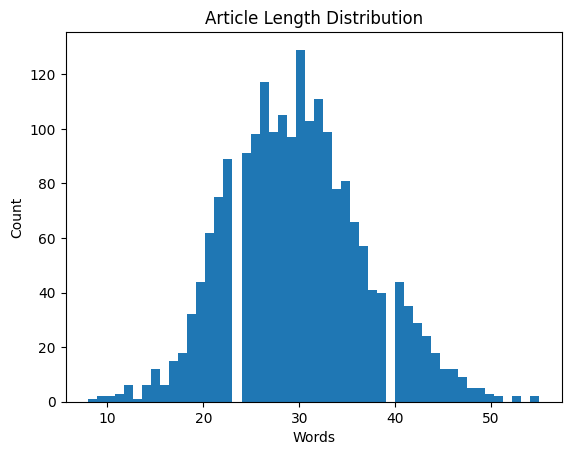

In [ ]:


data['length'] = data['input'].apply(lambda x: len(x.split()))
plt.hist(data['length'], bins=50)
plt.title("Article Length Distribution")
plt.xlabel("Words")
plt.ylabel("Count")
plt.show()

In [17]:
print(data['label'].value_counts())

label
impetigo                           90
psoriasis                          90
diabetes                           90
urinary tract infection            89
drug reaction                      89
allergy                            89
varicose veins                     89
hypertension                       89
chicken pox                        89
common cold                        88
bronchial asthma                   88
typhoid                            88
cervical spondylosis               87
dengue                             87
fungal infection                   87
gastroesophageal reflux disease    86
peptic ulcer disease               86
arthritis                          84
malaria                            84
pneumonia                          84
migraine                           79
jaundice                           69
acne                               46
dimorphic hemorrhoids              41
Name: count, dtype: int64


In [19]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'[^a-zA-Z0-9\s\.]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

data['clean_input'] = data['input'].apply(clean_text)

In [20]:
data

,label,input,length,clean_input
0,cervical spondylosis,I've been having a lot of pain in my neck and ...,32,ive been having a lot of pain in my neck and b...
1,impetigo,I have a rash on my face that is getting worse...,27,i have a rash on my face that is getting worse...
2,urinary tract infection,I have been urinating blood. I sometimes feel ...,23,i have been urinating blood. i sometimes feel ...
3,arthritis,I have been having trouble with my muscles and...,41,i have been having trouble with my muscles and...
4,dengue,I have been feeling really sick. My body hurts...,34,i have been feeling really sick. my body hurts...
...,...,...,...,...
1983,diabetes,I'm shaking and trembling all over. I've lost ...,25,im shaking and trembling all over. ive lost my...
1984,diabetes,"Particularly in the crevices of my skin, I hav...",25,particularly in the crevices of my skin i have...
1985,diabetes,I regularly experience these intense urges and...,23,i regularly experience these intense urges and...
1986,diabetes,"I have trouble breathing, especially outside. ...",24,i have trouble breathing especially outside. i...


In [64]:
def nltk_preprocess_pipeline(text):
        words = word_tokenize(text)
        words = [w.lower() for w in words if w.lower() not in stop_words and w.isalpha()]
        pos_tags = nltk.pos_tag(words)
        named_entities = ne_chunk(pos_tags)
        tokens = words
        return tokens, pos_tags, named_entities


In [67]:
sample = data['clean_input'][10]

tokens, pos_tags, named_entities = nltk_preprocess_pipeline(sample)

In [68]:
print("Tokens:", tokens[:20])
print("POS Tags:", pos_tags[:10])
print("Named Entities:", named_entities)

Tokens: ['ive', 'experiencing', 'stiffness', 'neck', 'joints', 'swollen', 'ive', 'also', 'experiencing', 'pain', 'walk']
POS Tags: [('ive', 'JJ'), ('experiencing', 'VBG'), ('stiffness', 'JJ'), ('neck', 'NN'), ('joints', 'NNS'), ('swollen', 'VBP'), ('ive', 'JJ'), ('also', 'RB'), ('experiencing', 'VBG'), ('pain', 'NN')]
Named Entities: (S
  ive/JJ
  experiencing/VBG
  stiffness/JJ
  neck/NN
  joints/NNS
  swollen/VBP
  ive/JJ
  also/RB
  experiencing/VBG
  pain/NN
  walk/NN)


label
impetigo                           90
psoriasis                          90
diabetes                           90
urinary tract infection            89
drug reaction                      89
allergy                            89
varicose veins                     89
hypertension                       89
chicken pox                        89
common cold                        88
bronchial asthma                   88
typhoid                            88
cervical spondylosis               87
dengue                             87
fungal infection                   87
gastroesophageal reflux disease    86
peptic ulcer disease               86
arthritis                          84
malaria                            84
pneumonia                          84
migraine                           79
jaundice                           69
acne                               46
dimorphic hemorrhoids              41
Name: count, dtype: int64


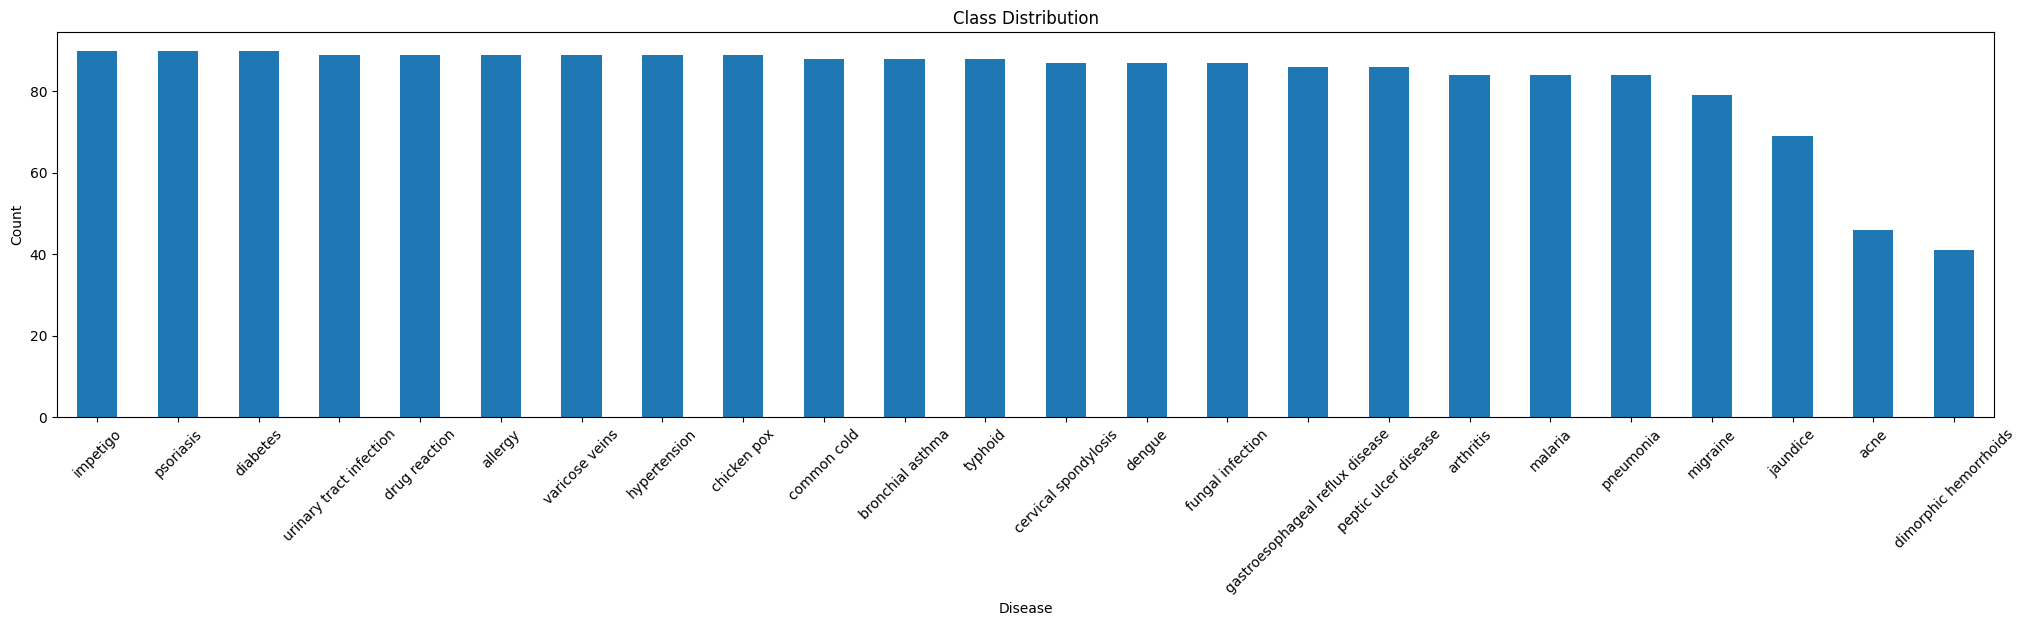

In [73]:
import matplotlib.pyplot as plt

label_counts = data['label'].value_counts()

print(label_counts)

plt.figure(figsize=(25,5))
label_counts.plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Disease")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

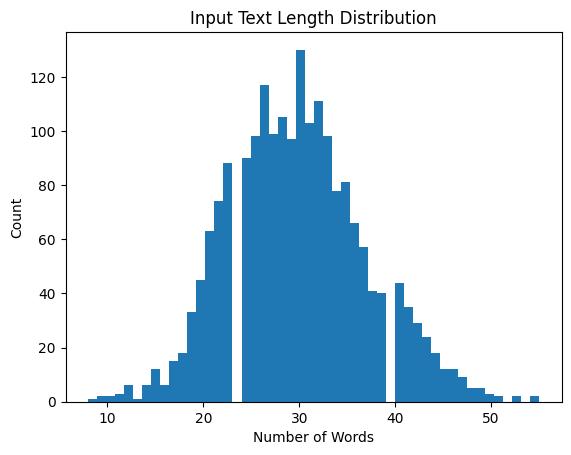

In [74]:
data['text_length'] = data['clean_input'].apply(lambda x: len(x.split()))

plt.hist(data['text_length'], bins=50)
plt.title("Input Text Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Count")
plt.show()

In [75]:
from collections import Counter

all_words = []

for text in data['clean_input']:
    all_words.extend(text.split())

word_counts = Counter(all_words)

print(word_counts.most_common(20))

[('and', 4309), ('my', 2958), ('i', 2955), ('a', 2303), ('have', 2050), ('been', 1818), ('ive', 1235), ('also', 915), ('of', 858), ('is', 824), ('to', 760), ('the', 707), ('really', 652), ('in', 650), ('are', 575), ('lot', 510), ('im', 509), ('has', 481), ('having', 476), ('skin', 454)]


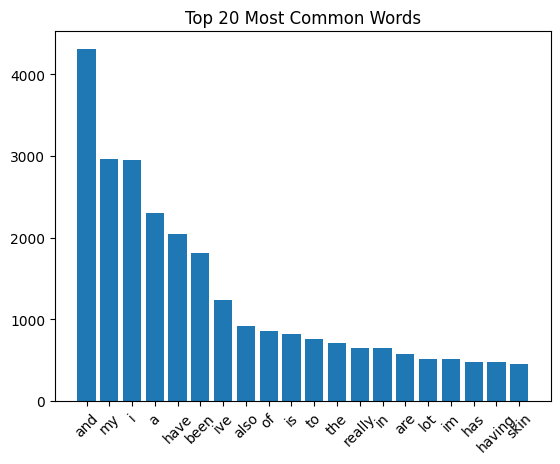

In [76]:
common_words = word_counts.most_common(20)

words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 20 Most Common Words")
plt.show()

In [78]:
for disease in data['label'].unique():
    texts = data[data['label'] == disease]['clean_input']
    
    words = []
    for t in texts:
        words.extend(t.split())
    
    print(f"\nTop words for {disease}:")
    print(Counter(words).most_common(10))


Top words for cervical spondylosis:
[('and', 272), ('my', 155), ('been', 143), ('have', 99), ('a', 89), ('ive', 85), ('pain', 85), ('i', 83), ('neck', 82), ('back', 75)]

Top words for impetigo:
[('and', 161), ('my', 136), ('i', 128), ('a', 116), ('have', 102), ('the', 88), ('are', 76), ('sores', 74), ('on', 66), ('to', 57)]

Top words for urinary tract infection:
[('i', 203), ('and', 157), ('my', 128), ('have', 102), ('to', 91), ('a', 90), ('been', 61), ('pee', 54), ('in', 53), ('the', 47)]

Top words for arthritis:
[('my', 195), ('been', 190), ('and', 127), ('have', 97), ('has', 96), ('to', 90), ('joints', 78), ('neck', 77), ('stiff.', 59), ('walking', 59)]

Top words for dengue:
[('and', 186), ('i', 178), ('my', 152), ('have', 134), ('a', 93), ('been', 58), ('pain', 54), ('is', 53), ('the', 43), ('on', 42)]

Top words for common cold:
[('and', 304), ('my', 248), ('a', 132), ('i', 130), ('ive', 123), ('been', 114), ('really', 87), ('is', 76), ('lot', 67), ('are', 61)]

Top words for

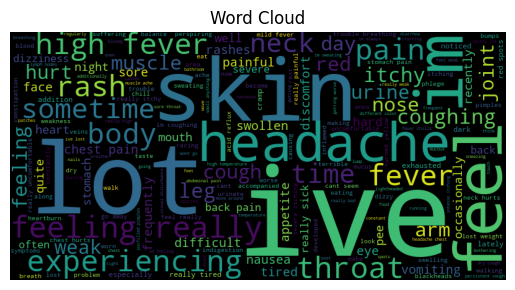

In [80]:
from wordcloud import WordCloud

text = " ".join(data['clean_input'])

wordcloud = WordCloud(width=800, height=400).generate(text)

plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud")
plt.show()